# Azure AD 

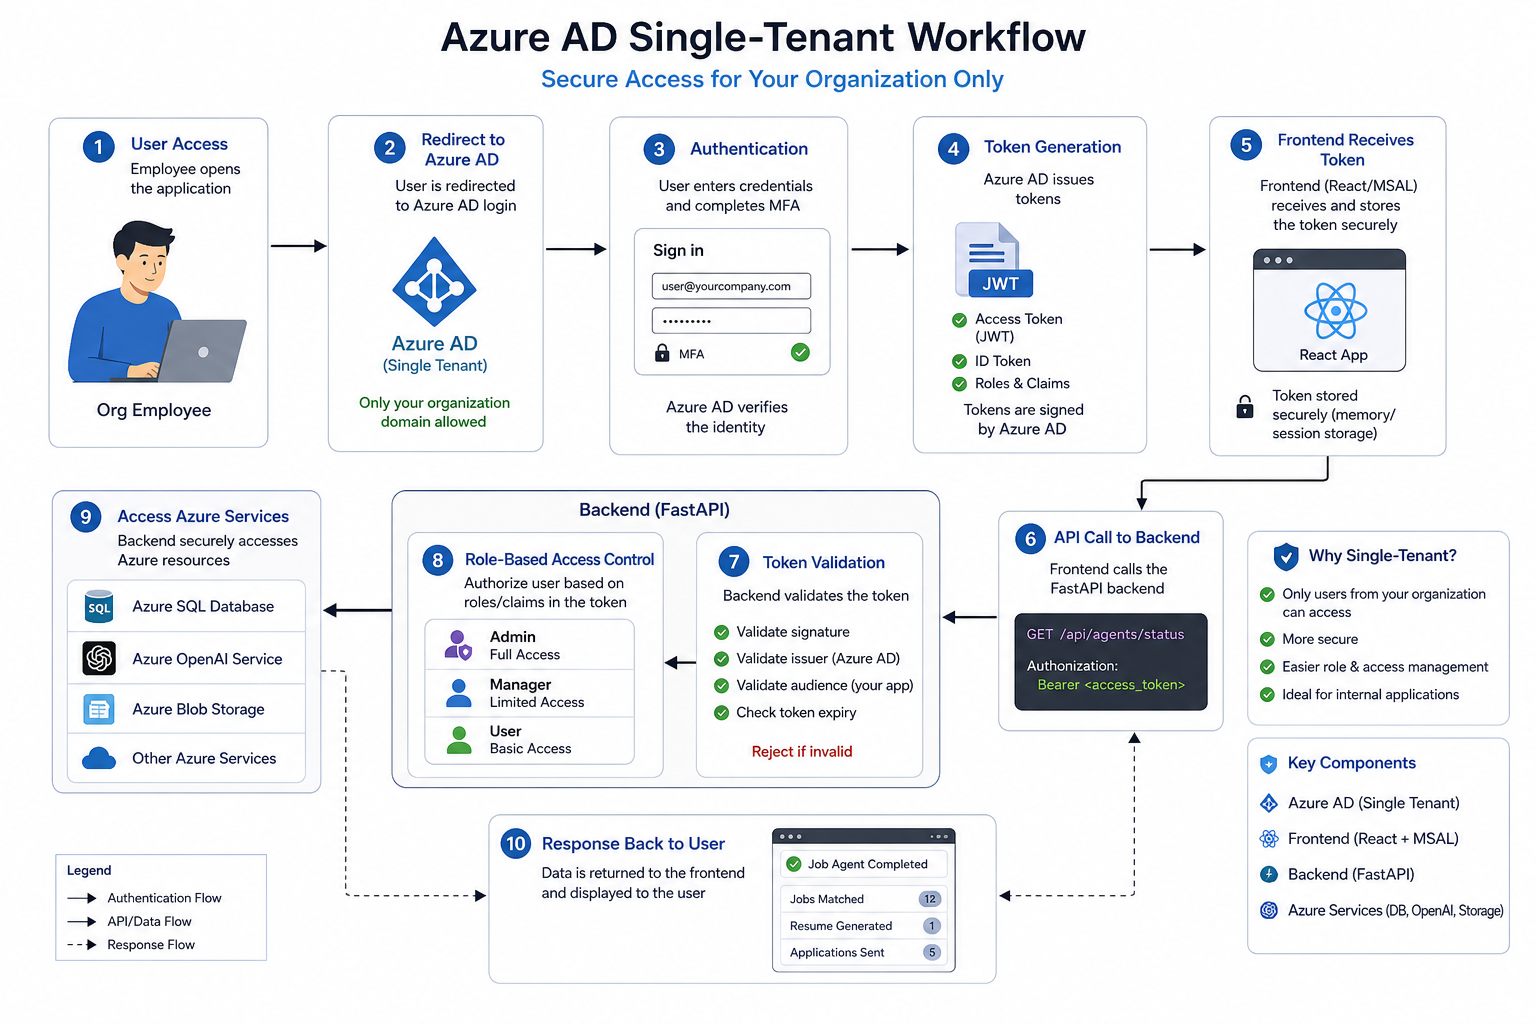

An Microsoft Azure Active Directory single-tenant workflow begins when a user from your organization opens the application, such as an internal dashboard or your AI agent platform, and the system checks whether the user is already authenticated; if not, the application immediately redirects the user to the Azure AD login page that is specifically configured for your tenant, which ensures that only users belonging to your company’s directory are allowed to proceed.

Once redirected, the user enters their organizational credentials, including email and password, and may also complete multi-factor authentication if it is enabled; at this stage Azure AD verifies the identity, evaluates any conditional access policies, and confirms that the login attempt complies with your organization’s security rules before granting access.

After successful authentication, Azure AD generates security tokens, primarily an ID token and an access token, where the ID token carries basic user identity information for the frontend while the access token, typically a JWT, contains critical details such as user roles, permissions, tenant information, and an expiration time, all digitally signed so that they cannot be altered.

These tokens are then sent back to the frontend application, which usually uses a library like MSAL to handle authentication, and the tokens are stored securely in memory or session storage so they can be used for subsequent API requests without repeatedly asking the user to log in.

When the frontend needs to interact with the backend, for example to trigger an AI job agent or fetch data, it includes the access token in the authorization header of the request, allowing the backend to understand who is making the request and what permissions they have.

The backend, such as a FastAPI service, does not blindly trust this request and instead performs strict validation of the token by checking its digital signature, confirming that it was issued by Azure AD, verifying that it is intended for the correct application, and ensuring that it has not expired; if any of these checks fail, the request is rejected immediately to prevent unauthorized access.

Once the token is validated, the backend extracts role and permission information from it and applies role-based access control, which determines what the user is allowed to do, meaning an admin might have full access to all features while a regular user might only be able to perform limited actions.

After authorization is confirmed, the backend proceeds to perform the requested operation by interacting with various Azure services such as databases for storing or retrieving information, storage services for handling files like resumes, or AI services for generating outputs, all within a secure and controlled environment.

Finally, the backend sends the processed response back to the frontend, where the application displays the results to the user, such as generated resumes, matched job listings, or automation outcomes, completing the full cycle of a secure, single-tenant authentication and authorization workflow that ensures only authorized users within your organization can access and use the system.


# Azure Key Vault


First, you store your secret (like a database password or API key) inside Azure Key Vault instead of putting it in your code. At this point, the secret is safely stored and no application can access it yet.

Next, your App Service application is given a Managed Identity. This is like giving your app its own secure login in Azure, so it can prove who it is without using usernames or passwords.

After that, you give permission in Key Vault to this Managed Identity. This step is important because it defines what your app is allowed to do. In most cases, you only allow it to read secrets.

Then, inside App Service configuration, instead of writing the actual secret value, you add a Key Vault reference. This is just a link pointing to the secret stored in Key Vault, not the secret itself.

When your application starts running, Azure automatically detects this reference. It uses the Managed Identity to securely connect to Key Vault, fetch the secret, and inject it into your application as an environment variable.

Finally, inside your code, you simply read the value like a normal environment variable. Your application does not need to know anything about Key Vault or authentication because Azure handles everything in the background.

# AZure Function 

In Azure Functions, functions run only when an event occurs, and the type is defined by that trigger. Common triggers include HTTP for APIs, timer for scheduled jobs, queue or Service Bus for message-based processing, and blob for file uploads. There are also triggers like Event Grid and Cosmos DB for reacting to changes in Azure services. Overall, Azure Functions provide an event-driven, scalable way to run code without managing servers.

Sure, let’s walk through it in the simplest way possible using your **10 PDF upload** example.

When you upload 10 PDFs into **Azure Blob Storage**, all the files are just stored there first. Nothing complex happens at this stage, it’s simply saving the files.

As soon as each PDF is uploaded, it automatically triggers a function in **Azure Functions**. Since you uploaded 10 files, this trigger happens 10 times, once for each file. This function does not do heavy work; it just takes the file information, like the file name or path, and sends a small message into a queue.

Now all 10 PDFs are represented as 10 messages inside the queue. The queue is like a waiting list that holds tasks safely.

After that, another function (queue-triggered) starts working. It reads one message at a time from the queue, picks the corresponding PDF, processes it, and completes the task. Multiple queue functions can run at the same time, so several PDFs can be processed in parallel instead of waiting in a long line.

Finally, after processing, the data from each PDF is stored in a search system like **Azure AI Search**, so it can be used later for searching or chatbot responses.

In simple terms, the flow is: you upload PDFs, each upload creates a task, the tasks go into a queue, and multiple workers pick those tasks and process them one by one or in parallel until everything is finished.
